# 🌟 Exercise 1: Duplicate Detection and Removal

In [3]:
import pandas as pd
titanic = pd.read_csv('titanic dataset\\train.csv')

In [4]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df = titanic[titanic.duplicated()==True]

In [6]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [7]:
titanic.shape

(891, 12)

In [8]:
titanic.drop_duplicates()
titanic.shape

(891, 12)

# 🌟 Exercise 2: Handling Missing Values

In [9]:
missing_data = titanic.isnull()
print(missing_data.head())

   PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0        False     False   False  False  False  False  False  False   False   
1        False     False   False  False  False  False  False  False   False   
2        False     False   False  False  False  False  False  False   False   
3        False     False   False  False  False  False  False  False   False   
4        False     False   False  False  False  False  False  False   False   

    Fare  Cabin  Embarked  
0  False   True     False  
1  False  False     False  
2  False   True     False  
3  False  False     False  
4  False   True     False  


In [14]:
# Count missing values in each column
missing_counts = df.isnull().sum()
print(missing_counts)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [17]:
df_drop = titanic.dropna()

In [19]:
df_drop.shape

(183, 12)

In [20]:
titanic.shape

(891, 12)

In [21]:
df_fill = titanic.fillna(0)

In [22]:
df_fill.shape

(891, 12)

# 🌟 Exercise 3: Feature Engineering

In [25]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
titanic['Family Size'] = titanic['SibSp'] + titanic['Parch'] + 1

In [11]:
titanic['Family Size'].head(10)

0    2
1    2
2    1
3    2
4    1
5    1
6    1
7    5
8    3
9    2
Name: Family Size, dtype: int64

In [12]:
titanic['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [13]:
titanic['Title'] = titanic['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

print(titanic[['Name', 'Title']].head())

                                                Name Title
0                            Braund, Mr. Owen Harris    Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs
2                             Heikkinen, Miss. Laina  Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs
4                           Allen, Mr. William Henry    Mr


In [14]:
titanic_cat = titanic.select_dtypes(include=['object']).columns

In [15]:
titanic_cat

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title'], dtype='object')

In [16]:
titanic[['Ticket', 'Cabin', 'Embarked']]

,Ticket,Cabin,Embarked
0,A/5 21171,NaN,S
1,PC 17599,C85,C
2,STON/O2. 3101282,NaN,S
3,113803,C123,S
4,373450,NaN,S
...,...,...,...
886,211536,NaN,S
887,112053,B42,S
888,W./C. 6607,NaN,S
889,111369,C148,C


In [17]:
titanic_encoded = pd.get_dummies(titanic, columns=['Sex', 'Embarked'], drop_first=True)

In [18]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')  

encoded_array = encoder.fit_transform(titanic[['Sex', 'Embarked', 'Title']])

# Create DataFrame
encoded_titanic = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Sex', 'Embarked', 'Title']))

# Concatenate with original data
titanic_final = pd.concat([titanic.drop(['Sex', 'Embarked', 'Title'], axis=1), encoded_titanic], axis=1)

In [19]:
titanic_final.head(10)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,6,0,3,"Moran, Mr. James",NaN,0,0,330877,8.4583,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,7,0,1,"McCarthy, Mr. Timothy J",54.0,0,0,17463,51.8625,E46,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,8,0,3,"Palsson, Master. Gosta Leonard",2.0,3,1,349909,21.0750,NaN,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,0,2,347742,11.1333,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,1,0,237736,30.0708,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# 🌟 Exercise 4: Outlier Detection and Handling


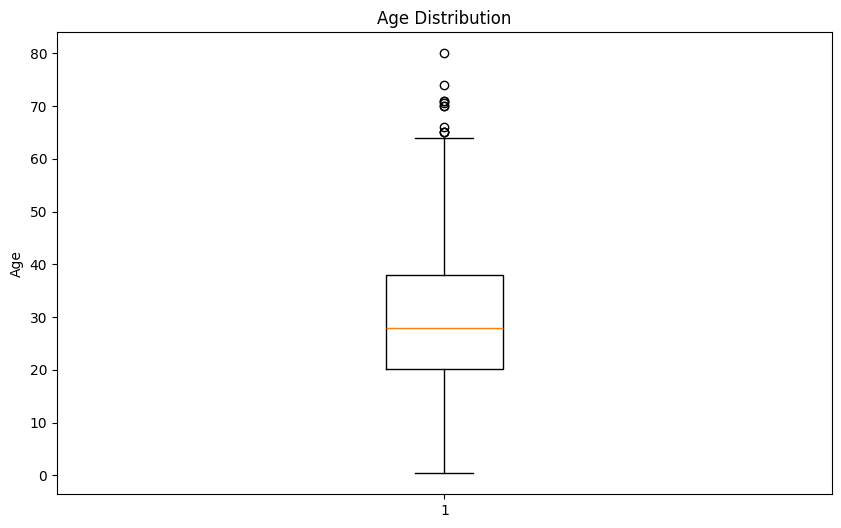

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot(titanic['Age'].dropna())
plt.title('Age Distribution')
plt.ylabel('Age')

plt.show()

Text(0, 0.5, 'Fare')

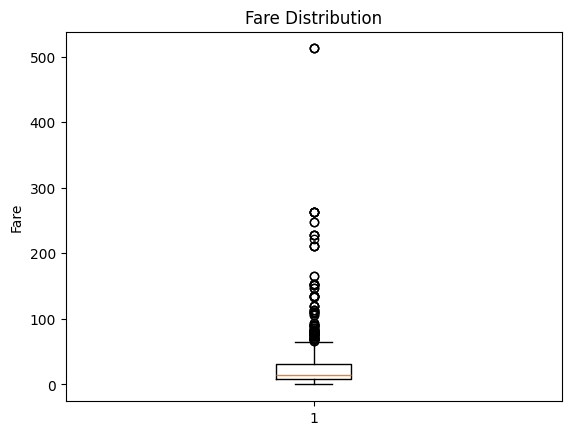

In [21]:
plt.boxplot(titanic['Fare'].dropna())
plt.title('Fare Distribution')
plt.ylabel('Fare')

In [22]:
Q1 = titanic['Fare'].quantile(0.25)
Q3 = titanic['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic_q = titanic[(titanic['Fare'] >= lower_bound) & (titanic['Fare'] <= upper_bound)]


In [23]:
titanic_q

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Mr
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,Mr


In [24]:
Q1 = titanic['Age'].quantile(0.25)
Q3 = titanic['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic_q2 = titanic[(titanic['Age'] >= lower_bound) & (titanic['Age'] <= upper_bound)]

In [25]:
titanic_q2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,6,Mrs
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,Mr


In [26]:
print(titanic.shape)
print(titanic_q.shape)
print(titanic_q2.shape)

(891, 14)
(775, 14)
(703, 14)


# 🌟 Exercise 5: Data Standardization and Normalization

In [27]:
import numpy as np
titanic['Fare'] = np.where(titanic['Fare'] < lower_bound, lower_bound, titanic['Fare'])
titanic['Fare'] = np.where(titanic['Fare'] > upper_bound, upper_bound, titanic['Fare'])

In [28]:
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_14100\2184073557.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)


In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler_standard = StandardScaler()

titanic['Age_scaled'] = scaler_standard.fit_transform(titanic[['Age']])

In [30]:
scaler_minmax = MinMaxScaler()
titanic['Fare_scaled'] = scaler_minmax.fit_transform(titanic[['Fare']])

In [31]:
print("Scaling completed!")
print("Age - Mean:", round(titanic['Age_scaled'].mean(), 2), "Std:", round(titanic['Age_scaled'].std(), 2))
print("Fare - Min:", round(titanic['Fare_scaled'].min(), 2), "Max:", round(titanic['Fare_scaled'].max(), 2))

Scaling completed!
Age - Mean: 0.0 Std: 1.0
Fare - Min: 0.0 Max: 1.0


# 🌟 Exercise 6: Feature Encoding

In [32]:
categorical_cols = titanic.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title']


In [33]:
for col in categorical_cols:
    if col in titanic.columns:
        print(f"\n{col}:")
        print(titanic[col].value_counts())
        print(f"Missing values: {titanic[col].isnull().sum()}")


Name:
Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64
Missing values: 0

Sex:
Sex
male      577
female    314
Name: count, dtype: int64
Missing values: 0

Ticket:
Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64
Missing values: 0

Cabin:
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..


In [34]:
titanic_encoded = pd.get_dummies(titanic, columns=['Sex', 'Embarked', 'Title'], 
                                prefix=['sex', 'embarked', 'title'])

print("Columns after one-hot encoding:")
print(titanic_encoded.columns.tolist())

Columns after one-hot encoding:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Family Size', 'Age_scaled', 'Fare_scaled', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'title_Capt', 'title_Col', 'title_Don', 'title_Dr', 'title_Jonkheer', 'title_Lady', 'title_Major', 'title_Master', 'title_Miss', 'title_Mlle', 'title_Mme', 'title_Mr', 'title_Mrs', 'title_Ms', 'title_Rev', 'title_Sir', 'title_the Countess']


# 🌟 Exercise 7: Data Transformation for Age Feature

In [40]:
bins = [0, 12, 18, 60, 100]
labels = ['child', 'teen', 'adult', 'senior']
titanic['Age_Group'] = pd.cut(titanic['Age'], bins=bins, labels=labels, right=False)

In [42]:
titanic.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Title,Age_scaled,Fare_scaled,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Mr,-0.565736,0.111861,adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,64.8125,C85,C,2,Mrs,0.663861,1.000000,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss,-0.258337,0.122276,adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Mrs,0.433312,0.819286,adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Mr,0.433312,0.124204,adult
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q,1,Mr,-0.104637,0.130504,adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1,Mr,1.893459,0.800193,adult
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,5,Master,-2.102733,0.325169,child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,3,Mrs,-0.181487,0.171777,adult
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,2,Mrs,-1.180535,0.463966,teen
